In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

pd.set_option("display.max_columns", 100)
pd.set_option("float_format", "{:.4f}".format)
sns.set_style("whitegrid")

# Data Loading 

In [2]:
_data = load_diabetes()
data = _data["data"]
feature_names = _data["feature_names"]

df = pd.DataFrame(data, columns=feature_names)
df["target"] = _data["target"]

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000


# EDA

In [3]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,152.1335
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,77.0930
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378,25.0000
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332,87.0000
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011,140.5000
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279,211.5000
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356,346.0000


<Axes: >

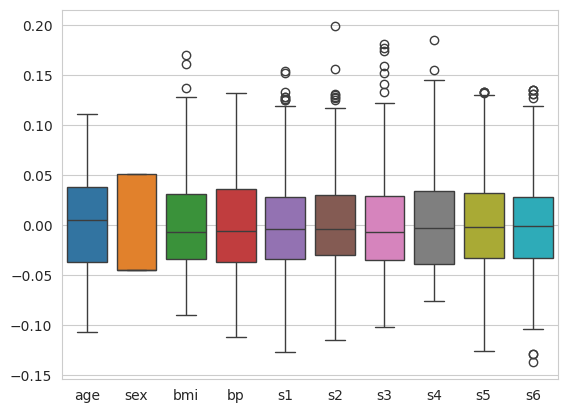

In [4]:
sns.boxplot(data=df.drop("target", axis=1))

## Correlation

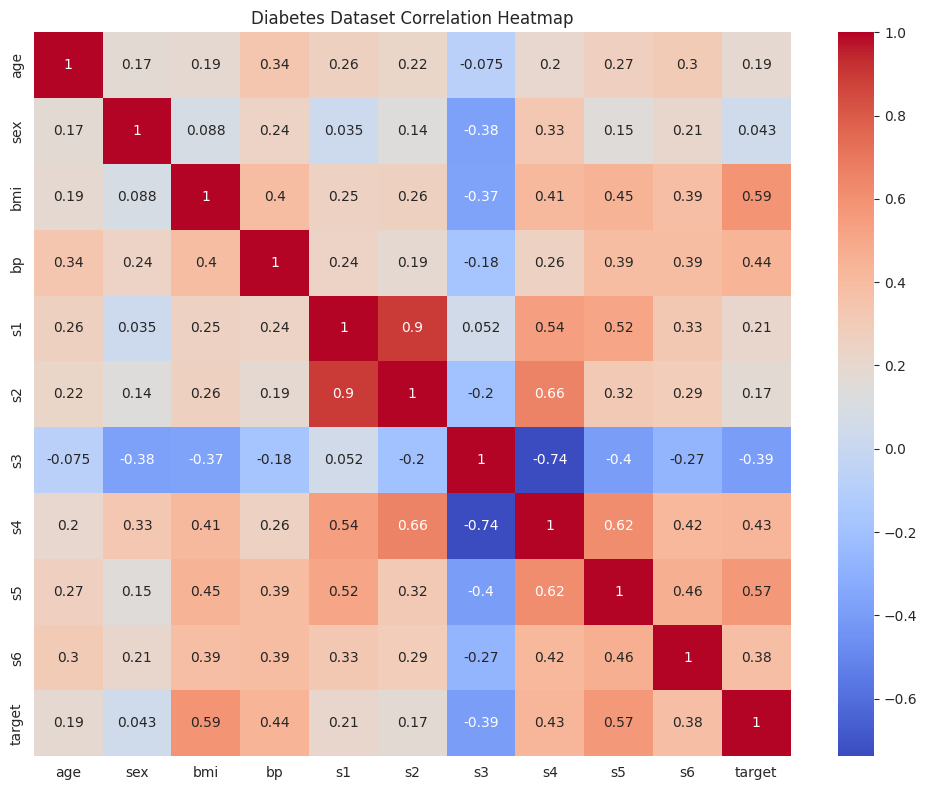

In [5]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    data=df.corr(),
    annot=True,
    cmap="coolwarm",
)

plt.title("Diabetes Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()

In [6]:
# Remove s2 due to multicollinearity with s1
df_scaled_ = df.drop(["s2"], axis=1)
df_scaled_.head()

,age,sex,bmi,bp,s1,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0081,-0.0026,-0.0320,-0.0466,135.0000


# Linear Regression

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm


## Dataset Definition

In [8]:
X = df.drop(["target", "s2"], axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(len(df), len(X_train), len(X_test))

442 353 89


In [10]:
print(353 + 89, 353 / 442)

442 0.7986425339366516


In [11]:
X_train.head()

,age,sex,bmi,bp,s1,s3,s4,s5,s6
17,0.0708,0.0507,0.0121,0.0563,0.0342,-0.0397,0.0343,0.0274,-0.0011
66,-0.0091,0.0507,-0.0181,-0.0332,-0.0208,-0.0729,0.0712,0.0003,0.0196
137,0.0054,-0.0446,0.0498,0.0976,-0.0153,-0.0066,-0.0026,0.0170,-0.0135
245,-0.0273,-0.0446,-0.0353,-0.0298,-0.0566,0.0302,-0.0395,-0.0499,-0.1295
31,-0.0237,-0.0446,-0.0655,-0.0814,-0.0387,0.0597,-0.0764,-0.0371,-0.0425


In [12]:
y_train.head()

17    144.0000
66    150.0000
137   280.0000
245   125.0000
31     59.0000
Name: target, dtype: float64

## Model

[Reference] https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
model.score(X_train, y_train)

0.5251250434558368

In [15]:
print(model.intercept_, model.coef_)

151.3010031750481 [  43.18112296 -241.37620081  555.70975248  344.64739047 -316.74521664
  -81.32562922  241.18350712  492.77226453   53.00257379]


In [16]:
X_train.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6'], dtype='str')

## Feature Selection 

**후진제거법 (Backward Elimination)**

1. 모든 변수로 회귀모형을 적합한다.
2. p-value가 가장 큰(가장 유의하지 않은) 변수를 하나 제거한다.
3. 남은 변수로 다시 적합한다 — 이때 **다른 변수의 p-value도 바뀐다**.
4. 모든 변수의 p-value가 유의수준(α = 0.05) 미만이 될 때까지 2~3을 반복한다.

p-value(계수·표준오차·유의확률)는 `statsmodels`로 계산하고,
선별은 **학습 데이터(X_train)로만** 수행해 정보 누출(leakage)을 막는다.

In [17]:
def backward_elimination(X, y, threshold=0.05):
    """p-value가 threshold보다 큰 변수를 하나씩 제거하며 재적합."""
    features = list(X.columns)
    step = 1
    while True:
        ols = sm.OLS(y, sm.add_constant(X[features])).fit()
        pvalues = ols.pvalues.drop("const")
        worst_p = pvalues.max()
        if worst_p > threshold:
            worst = pvalues.idxmax()
            print(
                f"[step {step}] 제거: {worst:5s} "
                f"(p-value = {worst_p:.4f}) | 남은 변수 {len(features)-1}개"
            )
            features.remove(worst)
            step += 1
        else:
            print(f"\n중단: 남은 변수 모두 p-value < {threshold}")
            break
    return features


selected_features = backward_elimination(X_train, y_train)
print("\n최종 선택 변수:", selected_features)

[step 1] 제거: s3    (p-value = 0.6057) | 남은 변수 8개
[step 2] 제거: age   (p-value = 0.5290) | 남은 변수 7개
[step 3] 제거: s6    (p-value = 0.4185) | 남은 변수 6개

중단: 남은 변수 모두 p-value < 0.05

최종 선택 변수: ['sex', 'bmi', 'bp', 's1', 's4', 's5']


**해석**
- 제거 순서: `s3`(p≈0.61) → `age`(p≈0.53) → `s6`(p≈0.42). 셋 다 유의하지 않아 탈락.
- 최종 선택: **sex, bmi, bp, s1, s4, s5** (모두 p < 0.05)

In [18]:
# 최종 선택 변수로 적합한 회귀 요약 (계수·표준오차·유의확률 확인)
final_ols = sm.OLS(y_train, sm.add_constant(X_train[selected_features])).fit()
print(final_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     63.30
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           9.13e-53
Time:                        05:01:08   Log-Likelihood:                -1907.8
No. Observations:                 353   AIC:                             3830.
Df Residuals:                     346   BIC:                             3857.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.4134      2.897     52.266      0.0

In [19]:
# 선택된 변수로 설계행렬 구성
X_ = X[selected_features]
X_.head()

,sex,bmi,bp,s1,s4,s5
0,0.0507,0.0617,0.0219,-0.0442,-0.0026,0.0199
1,-0.0446,-0.0515,-0.0263,-0.0084,-0.0395,-0.0683
2,0.0507,0.0445,-0.0057,-0.0456,-0.0026,0.0029
3,-0.0446,-0.0116,-0.0367,0.0122,0.0343,0.0227
4,-0.0446,-0.0364,0.0219,0.0039,-0.0026,-0.0320


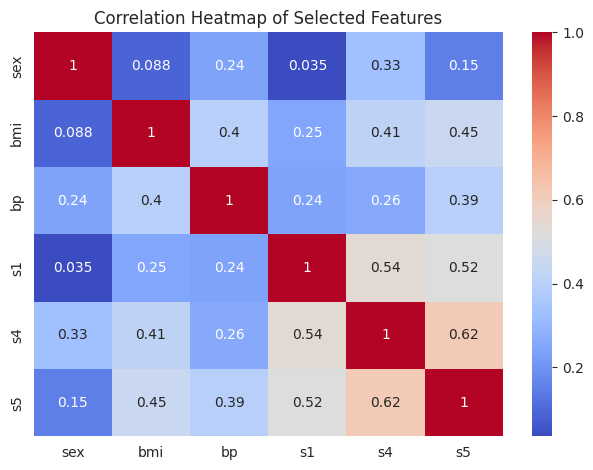

In [20]:
sns.heatmap(
    X_.corr(),
    annot=True,
    cmap="coolwarm",
)
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

## Retraining

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_, y, test_size=0.2, random_state=42
)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
print(model.score(X_train, y_train))
print(model.intercept_, model.coef_)

0.5233021444871312
151.41335824102657 [-229.69855255  570.11982041  363.49009725 -358.55217129  326.76990168
  513.93093011]


In [24]:
X_train.columns

Index(['sex', 'bmi', 'bp', 's1', 's4', 's5'], dtype='str')

## Prediction

In [25]:
pred = model.predict(X_test)

In [26]:
print(
    r2_score(y_test, pred),
    mean_squared_error(y_test, pred),
    mean_absolute_percentage_error(y_test, pred),
)

0.4546872806816573 2889.14953734482 0.37519332682268663


## Metrics

In [27]:
# 모델 설명력 비교
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("=== 모델의 설명계수(R²) ===")
print(f"훈련 데이터 R²: {train_r2:.4f}")
print(f"테스트 데이터 R²: {test_r2:.4f}")
print(f"R² 차이 (훈련 - 테스트): {train_r2 - test_r2:.4f}")

=== 모델의 설명계수(R²) ===
훈련 데이터 R²: 0.5233
테스트 데이터 R²: 0.4547
R² 차이 (훈련 - 테스트): 0.0686


In [28]:
# 예측 성능 비교
# 예측
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 훈련 데이터 평가
train_mse = mean_squared_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2_manual = r2_score(y_train, y_train_pred)

# 테스트 데이터 평가
test_mse = mean_squared_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2_manual = r2_score(y_test, y_test_pred)

print("\n=== 예측 성능 평가 ===")
print("훈련 데이터:")
print(f"  R²: {train_r2_manual:.4f}")
print(f"  MSE: {train_mse:.4f}")
print(f"  MAPE: {train_mape:.4f}")

print("\n테스트 데이터:")
print(f"  R²: {test_r2_manual:.4f}")
print(f"  MSE: {test_mse:.4f}")
print(f"  MAPE: {test_mape:.4f}")


=== 예측 성능 평가 ===
훈련 데이터:
  R²: 0.5233
  MSE: 2896.6059
  MAPE: 0.3888

테스트 데이터:
  R²: 0.4547
  MSE: 2889.1495
  MAPE: 0.3752


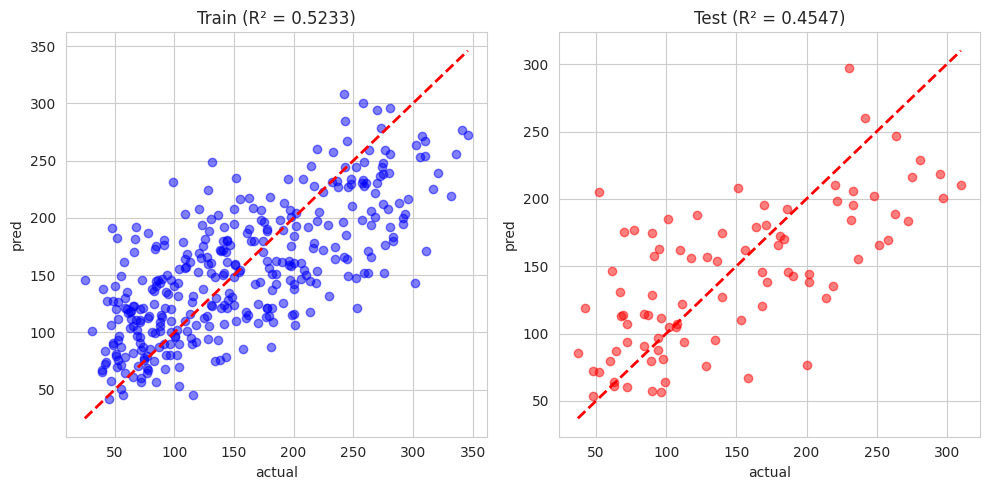


=== 모델 파라미터 ===
절편 (intercept): 151.4134

회귀계수 (coefficients):
  sex: -229.6986
  bmi: 570.1198
  bp: 363.4901
  s1: -358.5522
  s4: 326.7699
  s5: 513.9309


In [29]:
# R² 시각화
plt.figure(figsize=(10, 5))

# 훈련 데이터
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color="blue")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "r--", lw=2)
plt.xlabel("actual")
plt.ylabel("pred")
plt.title(f"Train (R² = {train_r2:.4f})")

# 테스트 데이터
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color="red")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("actual")
plt.ylabel("pred")
plt.title(f"Test (R² = {test_r2:.4f})")

plt.tight_layout()
plt.show()

# 회귀계수와 절편 출력
print("\n=== 모델 파라미터 ===")
print(f"절편 (intercept): {model.intercept_:.4f}")
print("\n회귀계수 (coefficients):")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

----
End of Documents